# **Discharge diagnostics**
### Ève Castonguay, LIRA

In [41]:
# This code establishes statistical diagnostics on the discharge DataSet created by the file [discharge_dset.ipynb], and also shows various plots.
# The main goal is to compare the swot discharge data with in-situ values available in the grdc dataset.
# Author: Ève Castonguay, LIRA (CNRS)
# Creation date: 2026-06-11 [YYYY-MM-DD]
# Version 0.1: AAAA-MM-JJ

In [42]:
# Imports
from datetime import datetime
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import glob 
import numpy as np
import netCDF4 as nc
from scipy.spatial import KDTree
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import math
from scipy import stats
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import geopy.distance
import random

### **Download dset**

#### Discharge DataSet

In [43]:
dset_version = 'v7'
dir_dset = '/obs/ecastonguay/scripts/global_dset_' + dset_version + '.nc'
dset_global = xr.open_dataset(dir_dset, engine="netcdf4") # discharge dataset

#### Save path

In [44]:
save_path_caler = '/obs/ecastonguay/scripts/figures/dset_global_' + dset_version + '/' 

### **Tests**

#### River names

In [45]:
df = dset_global[['river_global_g', 'id_global_s', 'river_global_s']].isel(id=slice(100, 500)).to_dataframe()
df['id_global_s'] = df['id_global_s'].astype('Int64')
print(df.to_string()) 

                     river_global_g  id_global_s              river_global_s
id                                                                          
4115281             DESCHUTES RIVER         <NA>                            
4115282             DESCHUTES RIVER         <NA>                            
4115290                CHELAN RIVER         <NA>                            
4115300              OKANOGAN RIVER  78262000051              okanogan river
4115301              OKANOGAN RIVER  78262000041              okanogan river
4115305           SIMILKAMEEN RIVER         <NA>                            
4115310                KETTLE RIVER         <NA>                            
4115311                KETTLE RIVER         <NA>                            
4115322              KOOTENAI RIVER  78268500191              kootenai river
4115330              FLATHEAD RIVER         <NA>                            
4115331              FLATHEAD RIVER  78266400071              flathead river

#### Number of stations matched with a reach

In [ ]:
r_ids = dset_global['id_global_s'].values 
sum_match = np.nansum(~np.isnan(r_ids))
sum_stations = len(r_ids)
print(f"{sum_match} matches for {sum_stations} stations")

# v3 : 807 matches for 5286 stations (thr = [0.5, 20, 75])
# v4 : 356 matches for 5286 stations
# v5 : 394 matches for 5286 stations (thr = [0.5, 20, 75, 50])
# v5_1 : 555 matches for 5286 stations (thr = [0.5, 20, 75, 100])
# v6 : 922 matches for 5286 stations
# v6_1 : 922 matches for 5286 stations
# v7 : 783 matches for 5286 stations (thr = [0.5, 20, 90, 50]) *
# v7_1 : 814 matches for 5286 stations (thr = [0.5, 20, 90, 100]) 
# v7_2 : 840 matches for 5286 stations (thr = [0.5, 20, 80, 50]) *
# v8 matt : 483 matches for 5286 stations (thr = [0.5, 10, 90, 10]) 
# v8_1 : 922 matches for 5286 stations (thr = [0.5, 20, 75, 100]) 

783 matches for 5286 stations


In [47]:
# when finished
# dset_global.close()

### **Statistics**

#### Selecting stations with sufficient swot-grdc temporal overlap

In [48]:
## Swot is ~21 days & grdc is ~daily. Both don't have data at the same time.
## Creating DataArrays containing dschg only when both have it.
co = 8 # number of correspondences

# Count the number of days for which there are swot & grdc mesures, per station
mask_coincide = dset_global.dschg_global_g.notnull() & dset_global.dschg_global_s.notnull() # Array of True/False. True where there are both swot & grdc data. .notnull() is pandas but works with np.nan
n_coincide = mask_coincide.sum(dim="time") # sum of Trues per station (5241,) # [tested]

# Compute the mean
mean_coincide = n_coincide.where(n_coincide != 0).mean() # 40.77 across all continent, ignoring zeros (WHEN there is a corresp., the avg number of time is ...) [tested]
mean_coincide_null = np.nanmean(n_coincide) # mean of 29.88 across all continents, including zeros [tested]

# Select stations where there are Co or more corresp.
ids_co = n_coincide.id.where(n_coincide >= co, drop=True) # get the list of station id where stats will be computed [tested] https://docs.xarray.dev/en/stable/generated/xarray.where.html
q_co_g = dset_global.sel(id=ids_co)["dschg_global_g"]
q_co_s = dset_global.sel(id=ids_co)["dschg_global_s"]
mask_coincide_co = mask_coincide.sel(id=ids_co) 

# DataArray of swot & grdc data only where both have data at the same time (rest is nan)
q_ol_g = q_co_g.where(mask_coincide_co) # ol : overlap
q_ol_s = q_co_s.where(mask_coincide_co)

# Retrieve (lat,lon) of stations
x_ol_s = dset_global.sel(id=ids_co)['geox_global_g'].values
y_ol_s = dset_global.sel(id=ids_co)['geoy_global_g'].values
x_ol_g = dset_global.sel(id=ids_co)['geox_global_s'].values
y_ol_g = dset_global.sel(id=ids_co)['geoy_global_s'].values

# Retrieve width of stations
w_ol_swr = dset_global.sel(id=ids_co)['width_global_s'].values

# Retrieve areas
area_ol_s = dset_global.sel(id=ids_co)['area_global_s'].values
area_ol_g = dset_global.sel(id=ids_co)['area_global_g'].values

# Retrieve ids
id_ol_s = dset_global.sel(id=ids_co)['id_global_s']
id_ol_g = dset_global.sel(id=ids_co).id.values

print(f"Number of stations with overlap higher or equal to {co} is {len(id_ol_g)}.")


Number of stations with overlap higher or equal to 8 is 715.


#### Stats

In [89]:
## Biais (daily mean error)
eps = 0.5 # to filter out the smaller discharges that would result in a value of inf (/0)
inf_mask = (q_ol_s >= eps) & (q_ol_g >= eps)
q_mask_g = q_ol_g.where(inf_mask) 
q_mask_s = q_ol_s.where(inf_mask) 
daily_err = (q_mask_s - q_mask_g) / q_mask_g # Nans will be ignored in the computations
bias = daily_err.mean(dim="time")*100

## MAE 
daily_err = np.absolute(q_ol_s-q_ol_g)
mae = daily_err.mean(dim="time")

## Temporal correlation (Pearson)
# Measuring temp. corr. only when grdc & swot both have data at a certain time 
r_matrix = xr.corr(q_ol_s, q_ol_g, dim='time') # [tested]

## KGE
def kge(sim, obs):
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    r = np.corrcoef(sim, obs)[0, 1]     # this is a correlation matrix. has size (2,2) for the 2 variables that are put as rows and columns. 
                                        # diagonals should always equal 1 because a given variable is perfectly correlated with itself.
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    kge_value = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    return kge_value #, r, alpha, beta
assert q_ol_g.shape == q_ol_s.shape

# Compute statistic
kge_matrix = np.array([ # q_ol_g.shape: (2776, 766)
    kge(q_ol_s[ii, :], q_ol_g[ii, :])
    for ii in range(q_ol_g.shape[0])
])

if kge_matrix.shape[0] != q_ol_g.shape[0] != q_ol_s.shape[0]:
    print("Error: Matrixes should have same number of rows. If the kge function deleted rows due to infinite values, adjust (lat,lon) accordingly.")
    
## SWOT amplitude
min_s = q_ol_s.min(dim="time",skipna=True)
max_s = q_ol_s.max(dim="time",skipna=True)
ampli_s = max_s-min_s

## GRDC amplitude
min_g = q_ol_g.min(dim="time",skipna=True)
max_g = q_ol_g.max(dim="time",skipna=True)
ampli_g = max_g-min_g

"""## Distance between GRDC and SWT coordinates - method 1
R = 6371.0084 # mean radius of the earth, https://ssd.jpl.nasa.gov/planets/phys_par.html
latg = np.radians(y_ol_g) 
long = np.radians(x_ol_g)
lats = np.radians(y_ol_s)
lons = np.radians(x_ol_s)

dlon = lons - long
dlat = lats - latg

a = np.sin(dlat / 2)**2 + np.cos(latg) * np.cos(lats) * np.sin(dlon / 2)**2
c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))

distance2 = R * c """

## Distance between GRDC and SWT coordinates - method 2
distance = np.full(len(y_ol_s),np.nan, dtype=np.float64)
for jj in range (len(y_ol_s)):
    coords_s = (y_ol_s[jj], x_ol_s[jj])
    coords_g = (y_ol_g[jj], x_ol_g[jj])
    distance[jj] = geopy.distance.geodesic(coords_s, coords_g).km

## NSE definition
def nse(sim, obs): # *** what happens if nans???
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    mse = np.mean((sim - obs)**2) # or : mean_squared_error(obs, sim)
    var_obs = np.std(obs)**2

    nse_value = 1 - mse/var_obs

    return nse_value #, r, alpha, beta
assert q_ol_g.shape == q_ol_s.shape

# Compute statistic
nse_array = np.array([ # q_ol_g.shape: (2776, 766)
    nse(q_ol_s[nn, :], q_ol_g[nn, :])
    for nn in range(q_ol_g.shape[0])
])

if nse_array.shape[0] != q_ol_g.shape[0] != q_ol_s.shape[0]:
    print("Error: Matrixes should have same number of rows. If the kge function deleted rows due to infinite values, adjust (lat,lon) accordingly.")
  

/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_1652/3778959731.py:28: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = np.std(sim) / np.std(obs)
/tmp/ipykernel_1652/3778959731.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.mean(sim) / np.mean(obs)
/tmp/ipykernel_1652/3778959731.py:89: RuntimeWarning: divide by zero encountered in scalar divide
  nse_value = 1 - mse/var_obs


### **Plots**

#### Time series of in-situ and swot 

Distance between reach and station is 5.53 km
The closest reach's id: 74230900011
Station coordinates are (32.3146,-90.9062)
Reach coordinates are (32.3447032532689,-90.9529691465538)


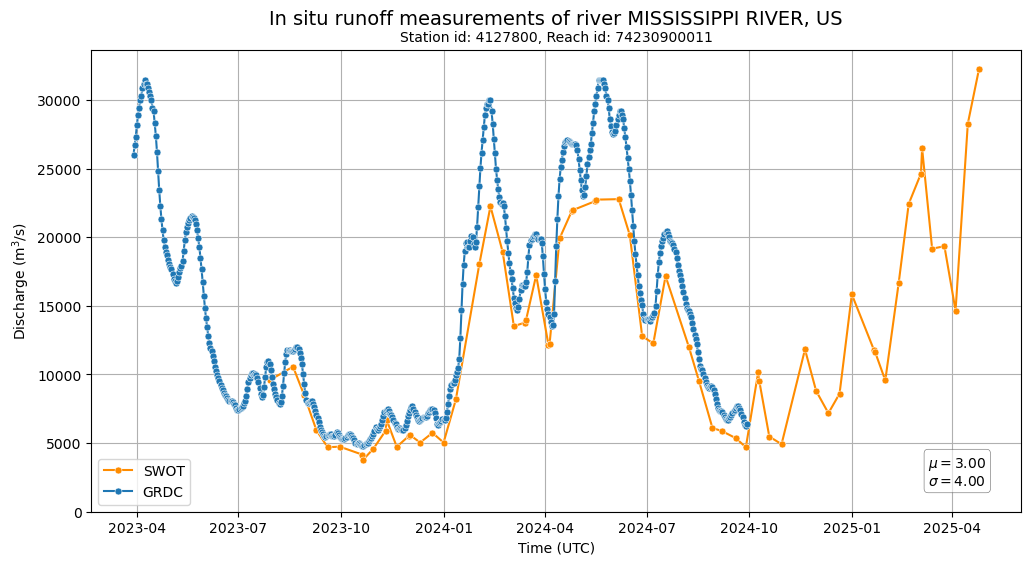

In [90]:
# Make sure the following variables are set correctly before running the code
list_stations_plot = [4127800] 
                                # SELECT stations in GRDC database to compare with SWOT data. Enter their stations id in int format.
                                # na
                                # 4127800 : article 3, fig 2a - Mississippi River near Baton Rouge, Louisiana, United States
                                # 4105850 : article 3, fig 2b - Kenai River near Soldotna, Alaska, United States
                                # eu
                                # 6139415 : article 3, fig 2c - Le Drac River near Grenoble, France
                                # sa
                                # 3626000 : amazonie, cours d'eau large de 3 km
                                # 3625000 : amazone
target_date_inf = "2023-07-01" # SELECT a time period for the plots
target_date_sup = "2024-09-21" # SWOT data : 2023-03-29 to 2025-05-02
use_target_date_filter = False # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available
save = False

# Making the plots          
for station_id in list_stations_plot:
    if station_id in dset_global['id'].values:
        
        # discharge data
        dset_global_id_flt = dset_global.sel(id=station_id)
        closest_reach_id = dset_global_id_flt['id_global_s'].values
        if ~np.isnan(closest_reach_id):
            closest_reach_id = closest_reach_id.astype(int) 
            #else: closest_reach_id = "NaN"
        
        # compute distance between reach and station
        coords_s = (dset_global_id_flt["geoy_global_s"].values,dset_global_id_flt["geox_global_s"].values)
        coords_g = (dset_global_id_flt["geoy_global_g"].values,dset_global_id_flt["geox_global_g"].values)
        if (np.any(np.isnan(coords_s)) or np.any(np.isnan(coords_g))):
            print("Distance couldn't be computed due to missing (lat,lon) values")
        else:
            distance = geopy.distance.geodesic(coords_s, coords_g).km
            print(f"Distance between reach and station is {distance:.2f} km")
        
        # print (lat,lon)
        print(f"The closest reach's id: {closest_reach_id}")
        print(f"Station coordinates are ({dset_global_id_flt['geoy_global_g'].values},{dset_global_id_flt['geox_global_g'].values})")
        print(f"Reach coordinates are ({dset_global_id_flt['geoy_global_s'].values},{dset_global_id_flt['geox_global_s'].values})")

        # get river name and country
        river_name = dset_global_id_flt['river_global_g'].values
        river_country = dset_global_id_flt['country_global_g'].values
            
        # plot
        plt.figure(figsize=(12, 6))
        plt.title(f"Station id: {station_id}, Reach id: {closest_reach_id}", fontsize=10) 
        plt.gca().text(0.5, 1.055, f"In situ runoff measurements of river {river_name}, {river_country}", transform=plt.gca().transAxes, ha="center", fontsize=14)
        plt.xlabel('Time (UTC)') 
        plt.ylabel(r'Discharge (m$^3$/s)')
        plt.grid(True)

        # text box with statistics
        mu = 3
        sigma = 4
        textstr = '\n'.join((
        r'$\mu=%.2f$' % (mu, ),
        r'$\sigma=%.2f$' % (sigma, )))
        props = dict(boxstyle='round', facecolor='w', alpha=0.6, lw=0.4) 
        plt.text(0.90, 0.05, textstr, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props)

        
        if use_target_date_filter: 
            # slicing data for the right id & time period
            target_datetime_inf = np.datetime64(target_date_inf, 'D')
            target_datetime_sup = np.datetime64(target_date_sup, 'D')
            dset_global_date_flt = dset_global_id_flt.sel(time=slice(target_date_inf,target_date_sup)) 
            
            # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
            dschg_swt = dset_global_date_flt['dschg_global_s']
            or_mask = ~np.isnan(dschg_swt.values)

            plt.plot(dset_global_date_flt['time'].values[or_mask],dschg_swt.values[or_mask], marker='o', markersize=5, label='SWOT', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
            plt.plot(dset_global_date_flt['time'].values, dset_global_date_flt['dschg_global_g'].values, marker='o', markersize=5, label='GRDC', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
            plt.legend()
            fig_name = f'discharge_s{station_id}_r{closest_reach_id}_{target_date_inf}_{target_date_sup}.png'
        else:
            # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
            dschg_swt = dset_global_id_flt['dschg_global_s']
            or_mask = ~np.isnan(dschg_swt.values)

            plt.plot(dset_global_id_flt['time'].values[or_mask],dschg_swt.values[or_mask], marker='o', markersize=5, label='SWOT', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
            plt.plot(dset_global_id_flt['time'].values, dset_global_id_flt['dschg_global_g'].values, marker='o', markersize=5, label='GRDC', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
            plt.legend()
            fig_name = f'discharge_s{station_id}_r{closest_reach_id}.png' #f'discharge_comparison_station{station_id}_r{closest_reach_id}.png'
        
        if save:
            plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
            print(f"Figure of station {station_id} saved in /obs/ecastonguay/scripts/figures") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")
        
        plt.ylim(0,None)
        plt.show()  
    else:
        print(f'Error: the station {station_id} is not in the list of station ids from the GRDC data')


#### Maximum discharge per reach for swot

/tmp/ipykernel_1652/1180075266.py:5: RuntimeWarning: All-NaN slice encountered
  q_max = np.nanmax(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data


Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3


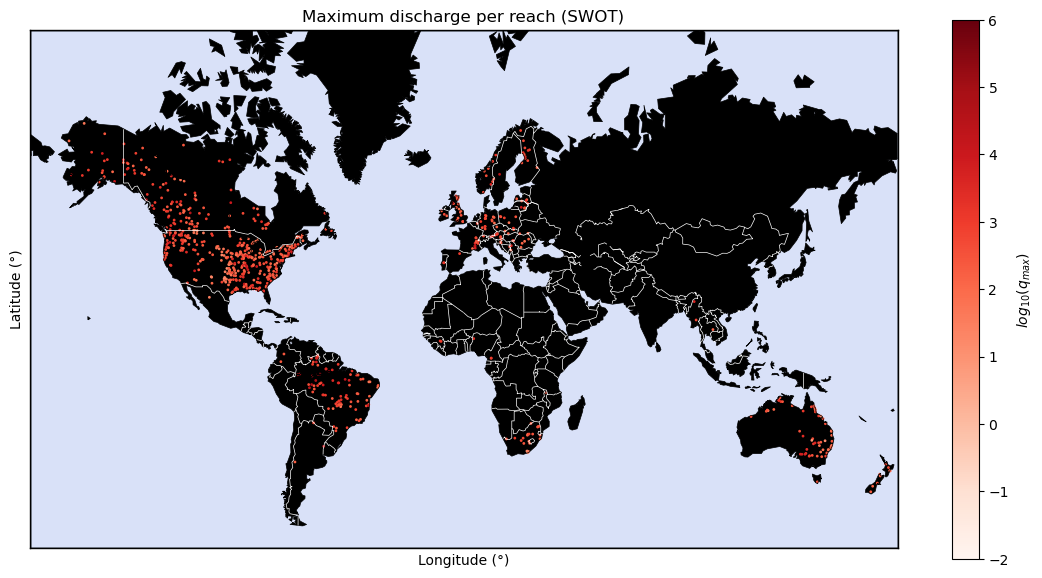

In [91]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
q_max = np.nanmax(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of reaches (not stations)
x_s = dset_global['geox_global_s'].values
y_s = dset_global['geoy_global_s'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(q_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{max})$')
plt.title("Maximum discharge per reach (SWOT)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'max_dschg_s_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3") 
plt.show()


#### Minimum discharge per reach for swot

/tmp/ipykernel_1652/4057754104.py:5: RuntimeWarning: All-NaN slice encountered
  q_min = np.nanmin(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data


Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3


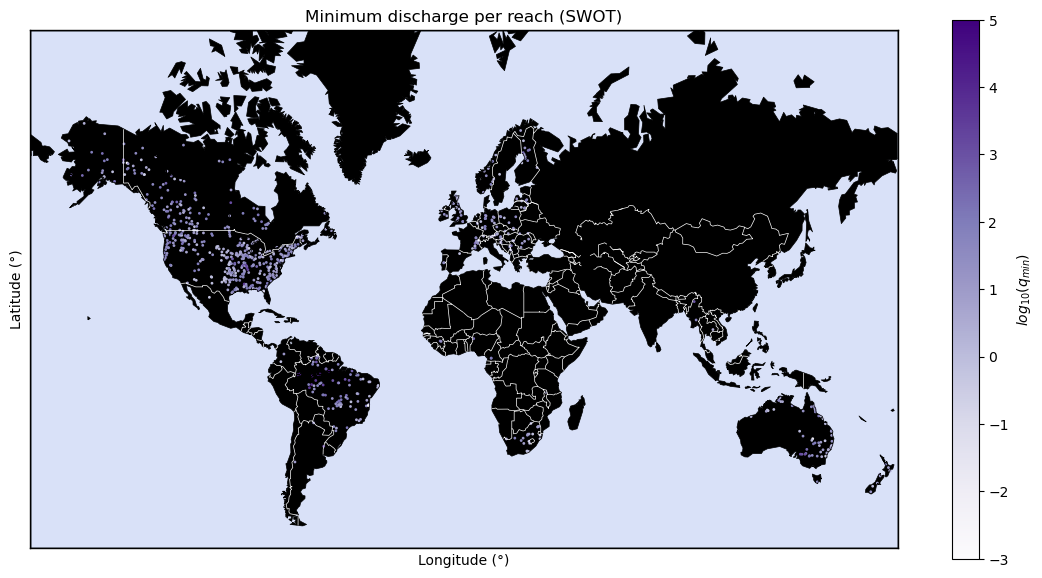

In [92]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
q_min = np.nanmin(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of reaches (not stations)
x_s = dset_global['geox_global_s'].values
y_s = dset_global['geoy_global_s'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(q_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{min})$')
plt.title("Minimum discharge per reach (SWOT)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'min_dschg_s_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3") 
plt.show()

#### Maximum discharge per station for grdc

/tmp/ipykernel_1652/952240667.py:5: RuntimeWarning: All-NaN slice encountered
  r_max = np.nanmax(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data
/tmp/ipykernel_1652/952240667.py:32: RuntimeWarning: divide by zero encountered in log10
  mymap = map.scatter(x, y, c=np.log10(r_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]


Figure saved in /obs/ecastonguay/scripts/figures


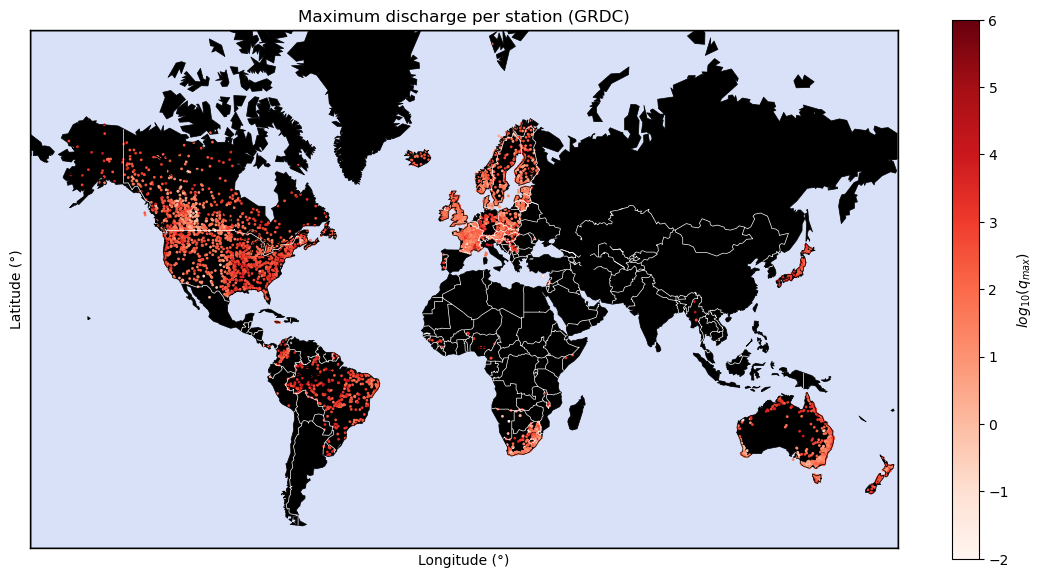

In [93]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
r_max = np.nanmax(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of stations
x_s = dset_global['geox_global_g'].values
y_s = dset_global['geoy_global_g'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(r_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{max})$')
plt.title("Maximum discharge per station (GRDC)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'max_dschg_g_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Minimum discharge per station for grdc

/tmp/ipykernel_1652/4168131312.py:5: RuntimeWarning: All-NaN slice encountered
  r_min = np.nanmin(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data
/tmp/ipykernel_1652/4168131312.py:32: RuntimeWarning: divide by zero encountered in log10
  mymap = map.scatter(x, y, c=np.log10(r_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]


Figure saved in /obs/ecastonguay/scripts/figures


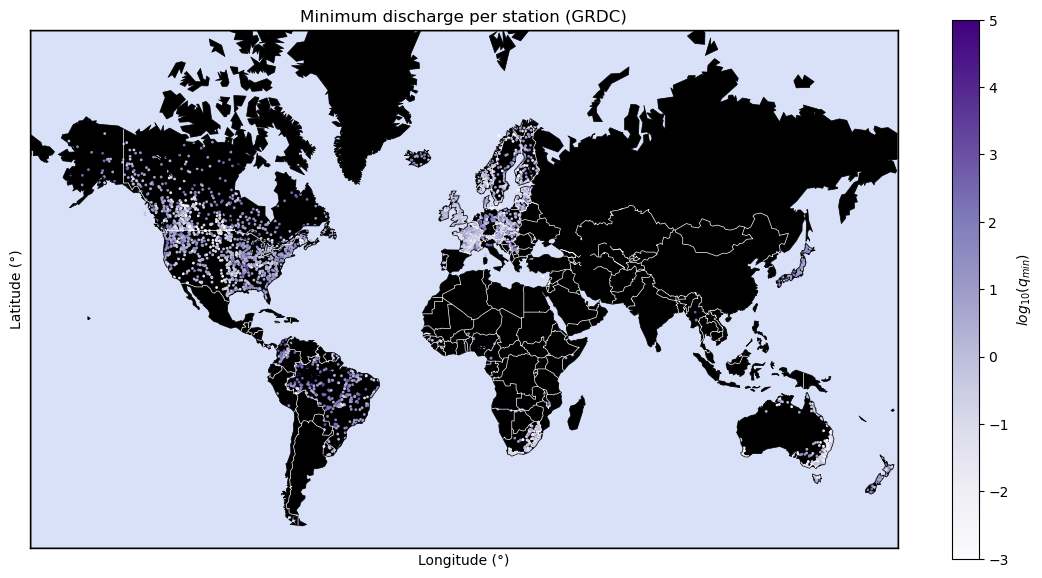

In [94]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
r_min = np.nanmin(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of stations
x_s = dset_global['geox_global_g'].values
y_s = dset_global['geoy_global_g'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(r_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{min})$')
plt.title("Minimum discharge per station (GRDC)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'min_dschg_g_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Multiplot of random time series

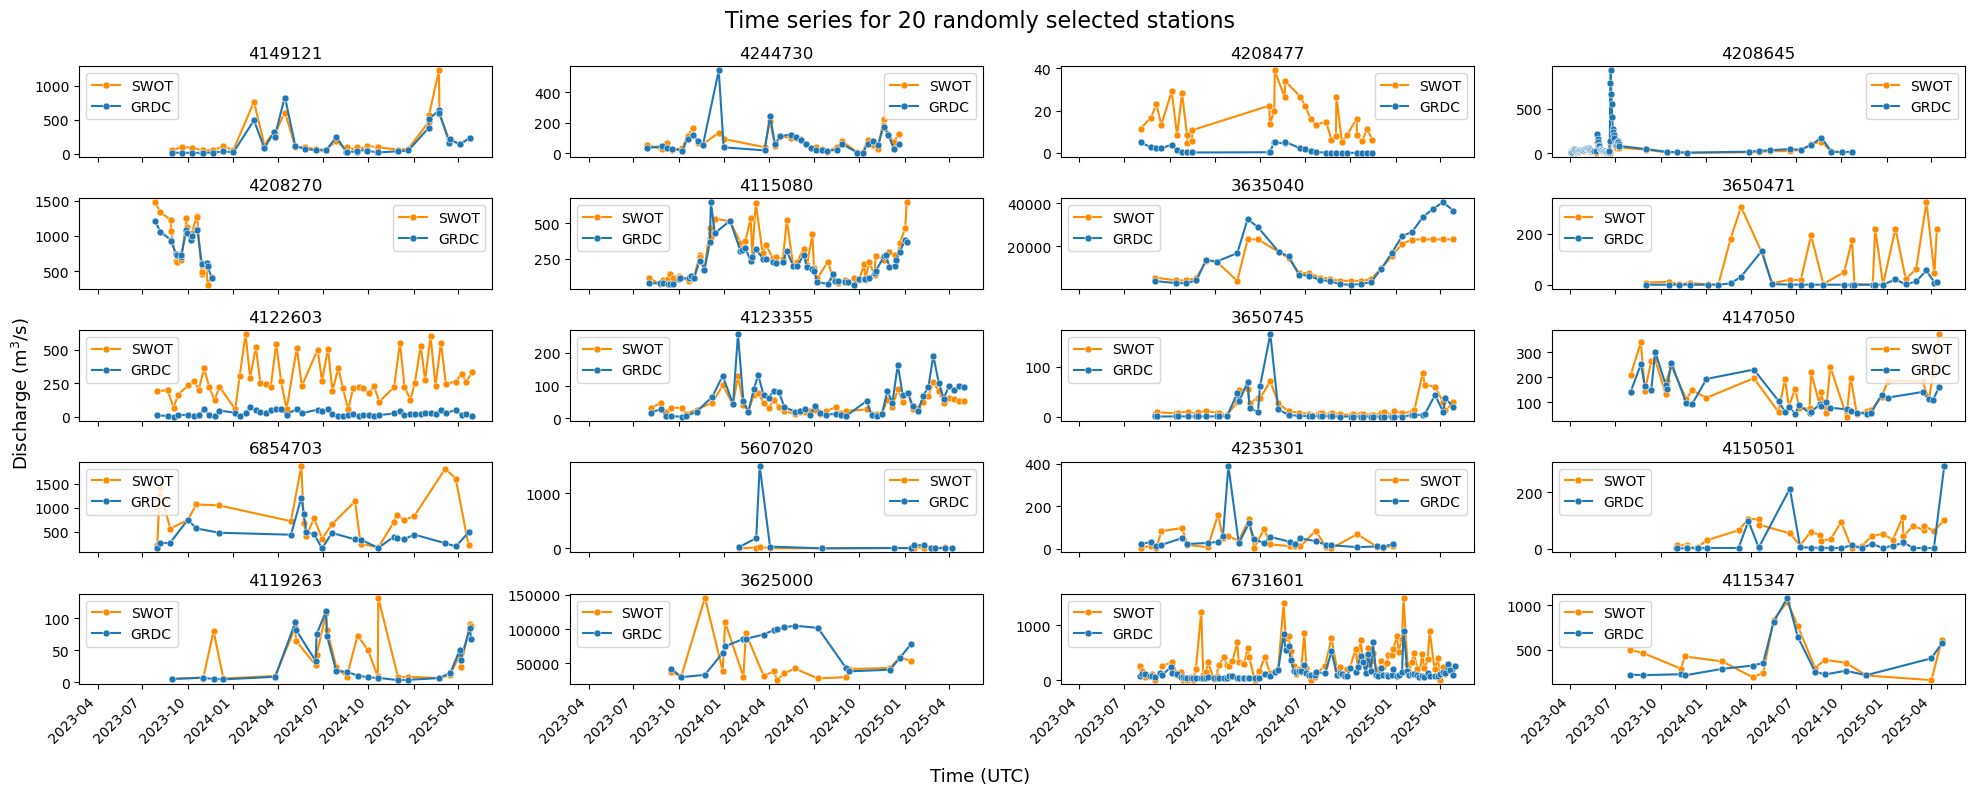

Saved.


<Figure size 640x480 with 0 Axes>

In [95]:
# Select n random ids
length = 5
width = 4
n_random = length*width
ids_random = random.sample(list(ids_co.values), k=n_random)

# Plot
fig, ax = plt.subplots(5,4,sharex=True, sharey=False, figsize=(20, 8))
fig.suptitle(f"Time series for {n_random} randomly selected stations", fontsize=16)
fig.supxlabel('Time (UTC)', fontsize=13)
fig.supylabel(r'Discharge (m$^3$/s)', fontsize=13, x=0.015)

i_id = 0
for l in range(length):
    for w in range(width):
        # select data
        station_id = ids_random[i_id].astype(int) 
        q_g = q_ol_g.sel(id=station_id)
        q_s = q_ol_s.sel(id=station_id)
        r_id = id_ol_s.sel(id=station_id).astype(int)

        # filtering nans out of the swot data
        nan_mask_s = ~np.isnan(q_s.values)
        nan_mask_g = ~np.isnan(q_g.values)

        # plot
        ax[l,w].set_title(f"{station_id}")
        ax[l,w].plot(q_s.time.values[nan_mask_s],q_s.values[nan_mask_s], marker='o', markersize=5, label='SWOT', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
        ax[l,w].plot(q_g.time.values[nan_mask_g], q_g.values[nan_mask_g], marker='o', markersize=5, label='GRDC', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
        ax[l,w].legend()

        # increment
        i_id += 1

# Skewed date labels 
for ax_row in ax:
    for ax_col in ax_row:
        plt.setp(ax_col.get_xticklabels(), rotation=45, ha='right')

# Save    
plt.tight_layout()
plt.show()  
fig_name = f'random_time_series.png' #f'discharge_comparison_station{station_id}_r{closest_reach_id}.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Saved.") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")


#### Swot's biais

Figure saved in /obs/ecastonguay/scripts/figures


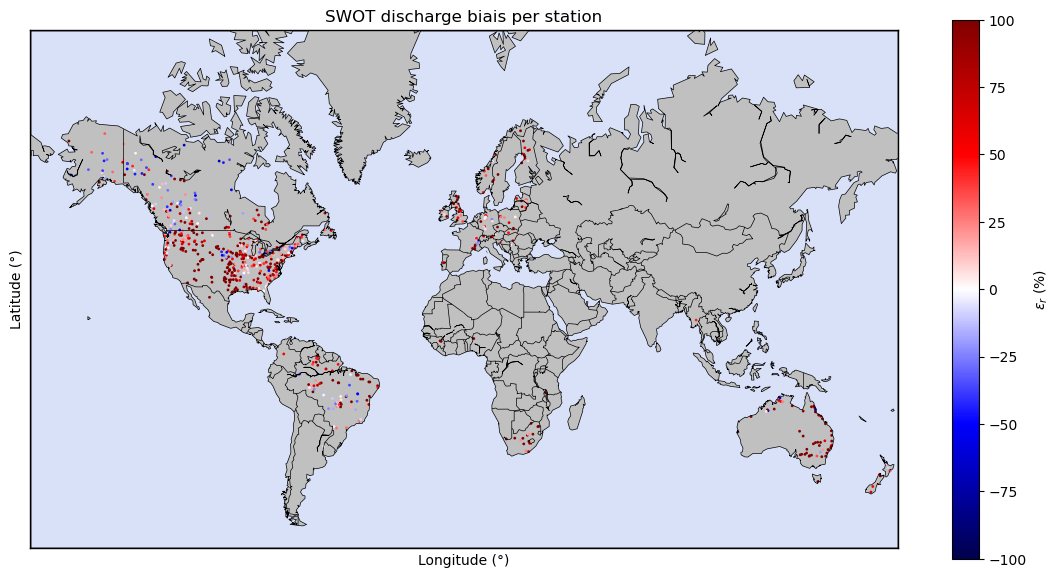

In [96]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='k',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='silver', lake_color='silver')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=bias, cmap='seismic', marker='o', alpha=1, s=1, vmin=-100,vmax=100) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$\varepsilon_r$ (%)')
plt.title("SWOT discharge biais per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'biais_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Mean absolute error (MAE)

Figure saved in /obs/ecastonguay/scripts/figures


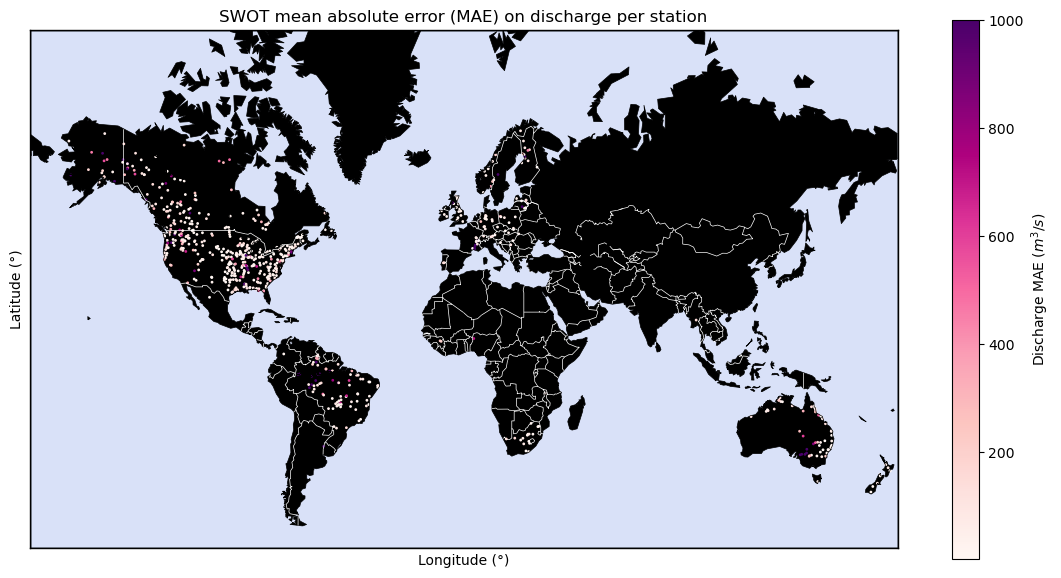

In [97]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=mae, cmap='RdPu', marker='o', alpha=1, s=1, vmax=1000) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'Discharge MAE ($m^3/s$)')
plt.title("SWOT mean absolute error (MAE) on discharge per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'mae_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### PDF of the differences

Error: NaN detected.


Figure saved in /obs/ecastonguay/scripts/figures


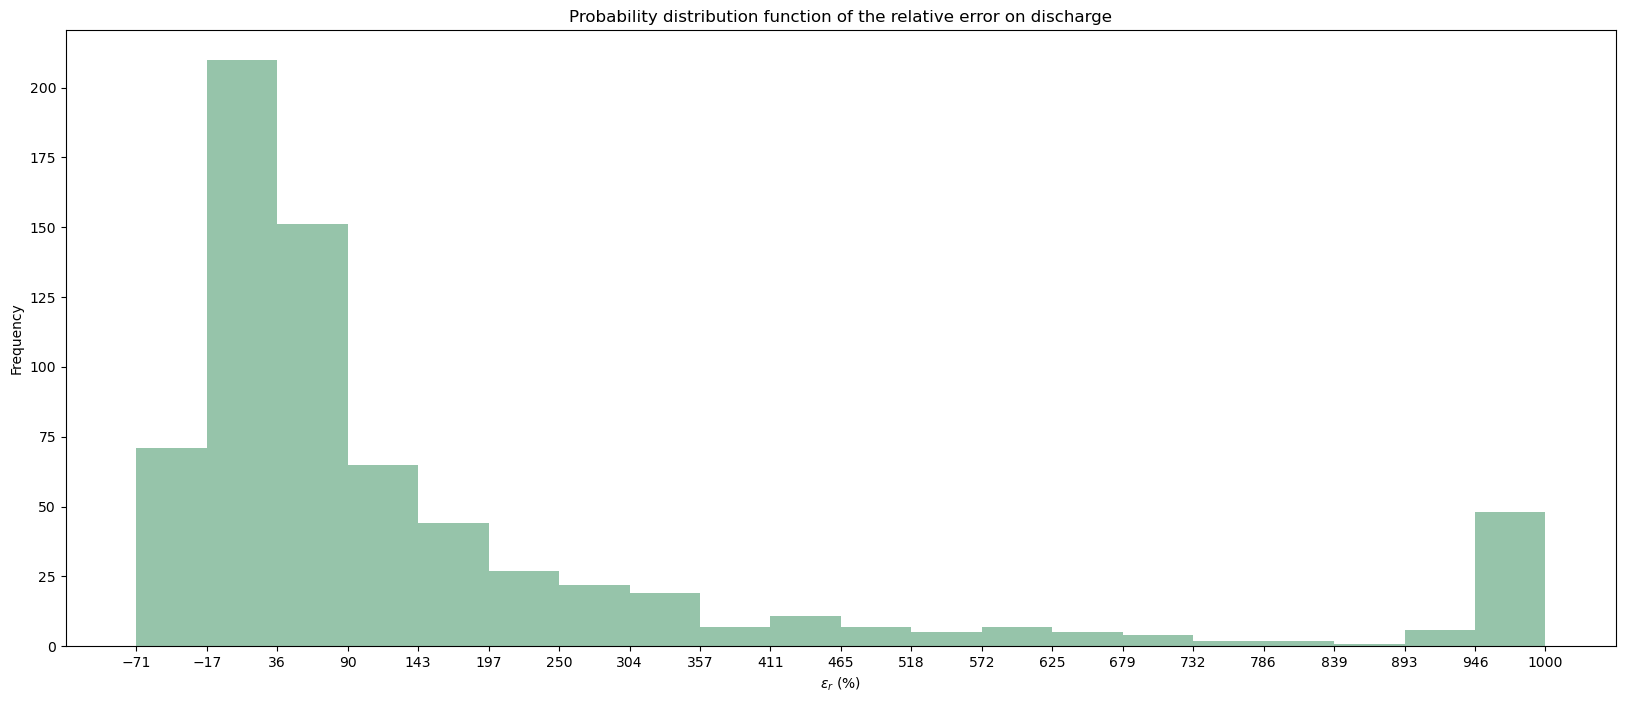

In [98]:
## For a given station, mean of the relative error.
## Clip the last bin: https://stackoverflow.com/questions/71818401/set-the-last-bin-of-histogram-to-a-range-to-include-all-large-values-seaborn-ma
## *** add a + to the last bin so that we know 

# Compute statistic
mean_arr = bias.values

if np.isnan(mean_arr).any():
    print("Error: NaN detected.")

# Clipping the very high values (including infinites) to a defined maximum
max_err = 1000
min_err = np.nanmin(mean_arr)
clip_sum = np.clip(mean_arr,min_err,max_err)

"""# Check the number of stations containing errors bigger than 100000
ids_co = sum_err.id.where(sum_err > 15000, drop=True)
max_sum = np.nanmax(sum_err)
min_sum = np.nanmin(sum_err)
print(min_sum,max_sum)
step = np.absolute(np.max(daily_err)-np.min(daily_err))/50
my_bins = np.arange(np.min(daily_err),np.max(daily_err),step)"""

# Plot
plt.figure(figsize=(20, 8))
n_bins = 20
step = (max_err-min_err)/n_bins
my_bins = np.arange(min_err,max_err+1,step)
plt.hist(clip_sum, bins=my_bins, color = 'seagreen', alpha=0.5)
#plt.title(f"In situ runoff measurements of station {station_id} and the SWOT L4 consensus discharge \nof it's nearest corresponding reach {closest_reach_id}") 
plt.xticks(my_bins)
plt.xlabel(r'$\varepsilon_r$ (%)') 
plt.ylabel('Frequency')
plt.title("Probability distribution function of the relative error on discharge") 

# Save
fig_name = f'pdf_rel_err.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


#### Temporal correlation

Figure saved in /obs/ecastonguay/scripts/figures


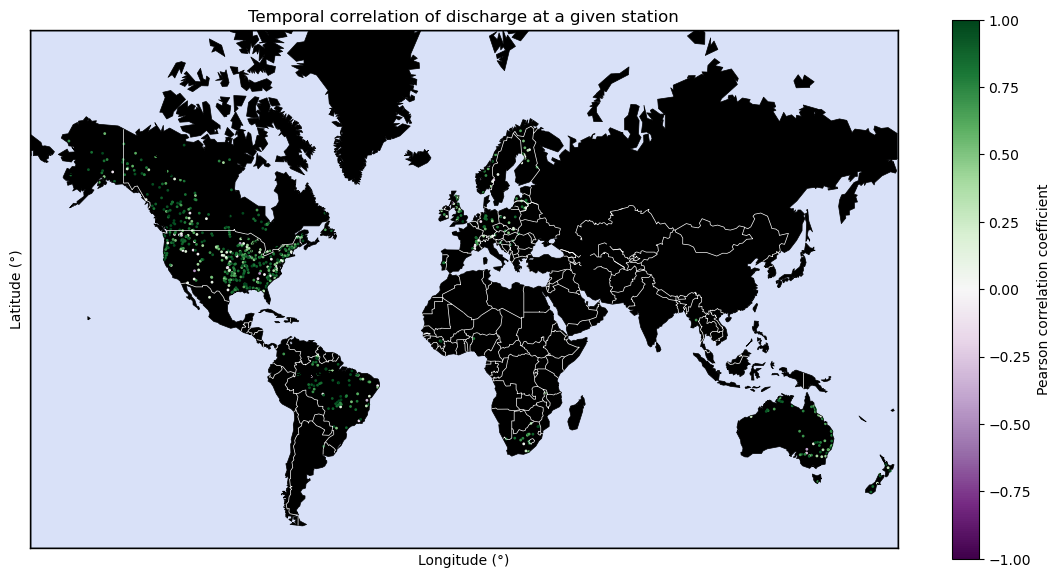

In [99]:
## If grdc discharge at a certain reach increases, does swot data do too?
## Computing Pearson corr. coeff. (linear correlation coefficient) for every station.
## https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=r_matrix, cmap='PRGn', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='Pearson correlation coefficient')
plt.title("Temporal correlation of discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'temp_corr_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Kling–Gupta Efficiency (KGE) coefficient

Figure saved.


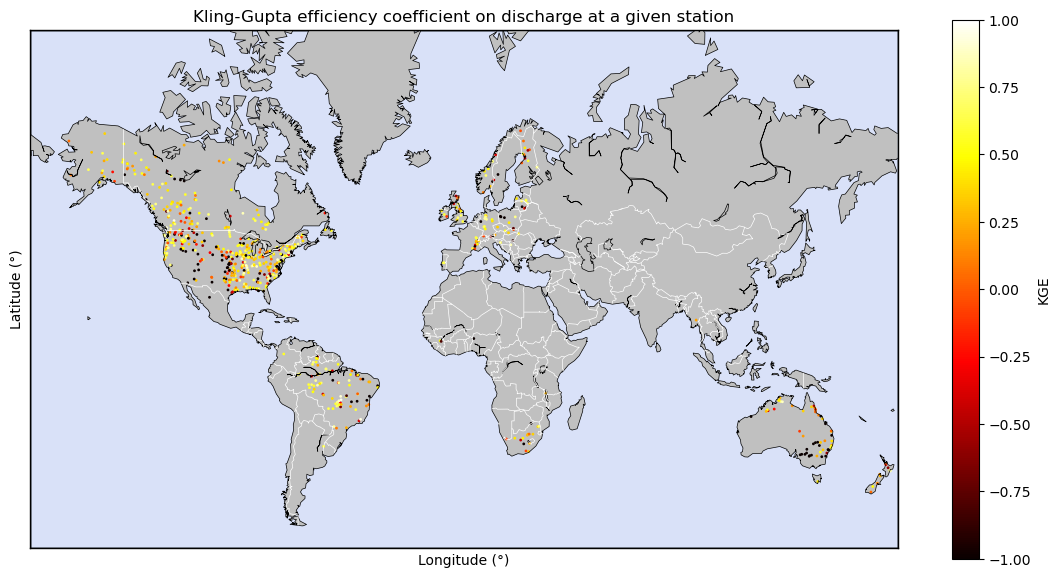

In [100]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='silver', lake_color='silver')
#map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=kge_matrix, cmap='hot', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='KGE')
plt.title("Kling-Gupta efficiency coefficient on discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'kge_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()

#### (10 best KGE)

In [101]:
# KGE
kge2 = np.where(np.isnan(kge_matrix), -np.inf, kge_matrix)

# Ids of the n best
n_best = 10
print("-> Stations having the best KGE (worst to best):")
ind_best = np.argpartition(kge2, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(kge2[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
assert id_ol_g.shape == kge2.shape
kge_10_best = []
kge_10_best.append(id_ol_g[ind_best_sorted])
print(kge_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. KGE value: {kge2[ind_best_sorted][b]}")

# Median of the distribution
median_da = np.nanmedian(kge_matrix) # using kge_matrix with nan values, not kge2 
median_id_g = id_ol_g[kge_matrix==median_da]
print("-> Median value")
print(f"Station id: {median_id_g}. KGE value: {median_da}")

## Results for n best:
# [6854101, 4127502, 3666500, 2589700, 4123202, 3649619, 4245950, 6122380, 3652870, 3649424]
## Results for median: 
# 3635451

-> Stations having the best KGE (worst to best):
[array([4123300, 4127503, 4147720, 4127502, 4123202, 3649619, 4245950,
       4207020, 3652870, 3649424])]
Station id: 4123300. KGE value: 0.8797176660246212
Station id: 4127503. KGE value: 0.8925210714298935
Station id: 4147720. KGE value: 0.8933465518680402
Station id: 4127502. KGE value: 0.8994265928476851
Station id: 4123202. KGE value: 0.9104326571160282
Station id: 3649619. KGE value: 0.9118606399113878
Station id: 4245950. KGE value: 0.9186411346943373
Station id: 4207020. KGE value: 0.9419875597884041
Station id: 3652870. KGE value: 0.942076961782238
Station id: 3649424. KGE value: 0.9598945860886638
-> Median value
Station id: []. KGE value: 0.3501349799750475


#### Scatter plot function of discharge

/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


Figure saved in /obs/ecastonguay/scripts/figures


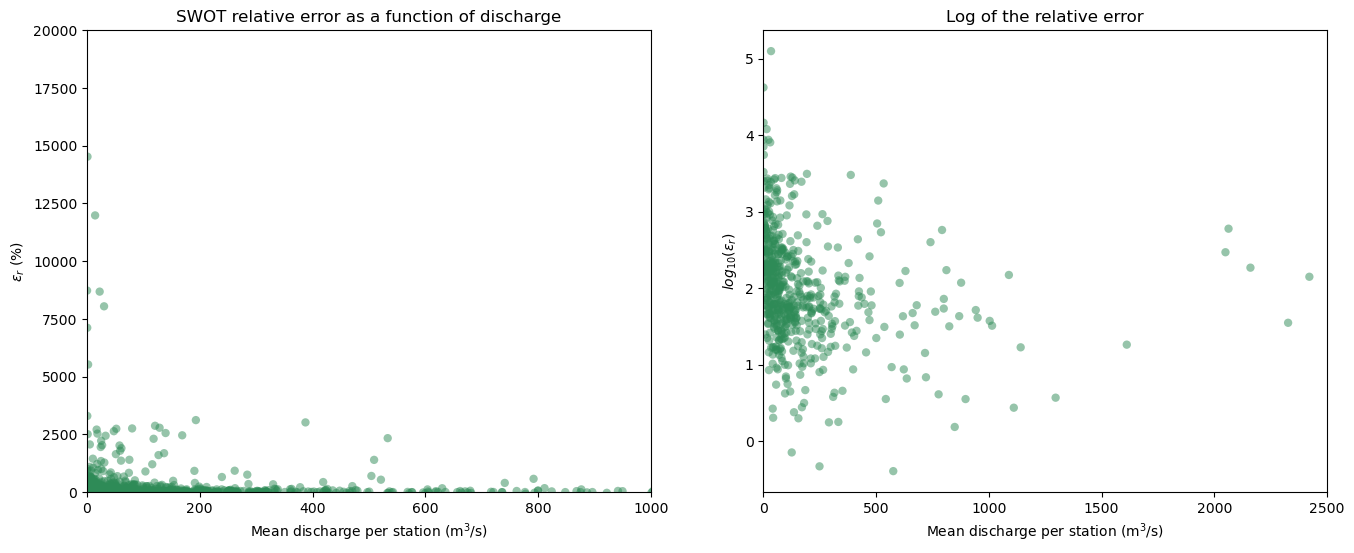

In [102]:
# Mean discharge of the river (y-axis) -> grdc data
daily_dschg = q_ol_g
mean_dschg = daily_dschg.mean(dim="time") # (2840,)

# River discharge min and max (y-axis limits)
max_dschg = np.max(mean_dschg) # 139024.55
min_dschg = np.min(mean_dschg) # 0

# Compute statistic
log_err = np.log10(bias) # (2840,)

# Scatter plot
fig, ax = plt.subplots(1,2,sharex=False, sharey=False, figsize=(16, 6))
# fig. full
ax[0].scatter(mean_dschg, bias, c='seagreen', alpha=0.5, edgecolors='none')
ax[0].set_xlim((0,1000)) # truncate 
ax[0].set_ylim((0,20000)) # truncate 
ax[0].set_title("SWOT relative error as a function of discharge") 
ax[0].set_xlabel(r'Mean discharge per station (m$^3$/s)')
ax[0].set_ylabel(r'$\varepsilon_r$ (%)')
# fig. truncated
ax[1].scatter(mean_dschg, log_err, c='seagreen', alpha=0.5, edgecolors='none')
ax[1].set_xlim((0,2500)) # truncate 
ax[1].set_title("Log of the relative error") 
ax[1].set_xlabel(r'Mean discharge per station (m$^3$/s)')
ax[1].set_ylabel(r'$log_{10}(\varepsilon_r)$')

# Save
fig_name = f'sct_dschg.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Relative error vs. width

Figure saved in /obs/ecastonguay/scripts/figures


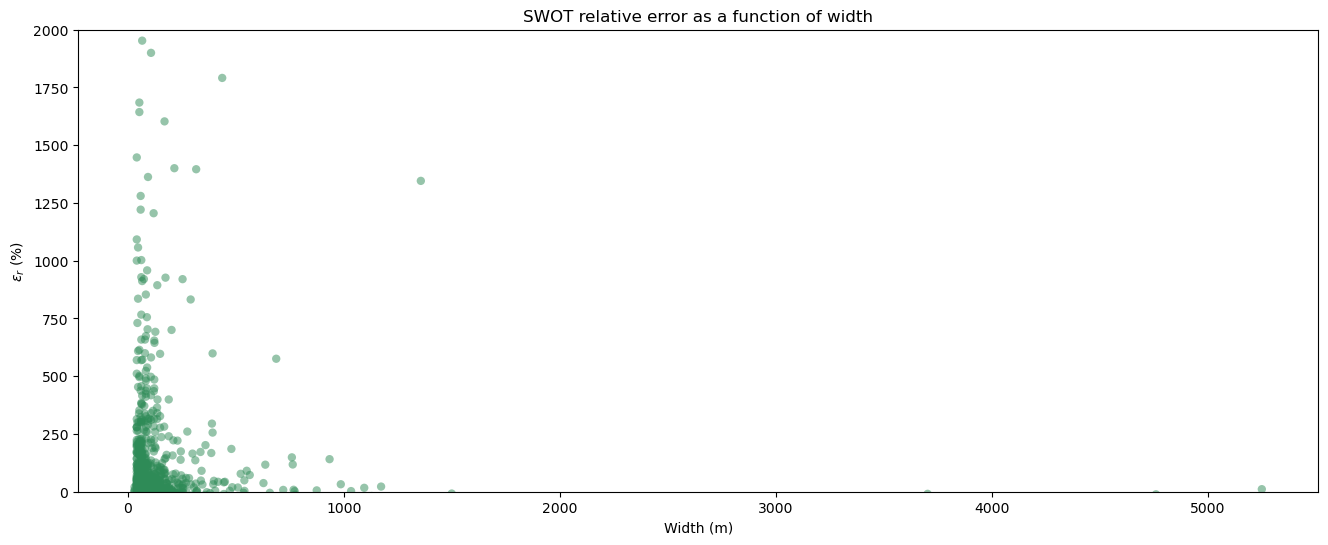

In [103]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(w_ol_swr, bias, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((0,2000))
plt.title("SWOT relative error as a function of width") 
plt.xlabel(r'Width (m)')
plt.ylabel(r'$\varepsilon_r$ (%)')

# Save
fig_name = f'sct_w.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Annual amplitude

Figure saved.


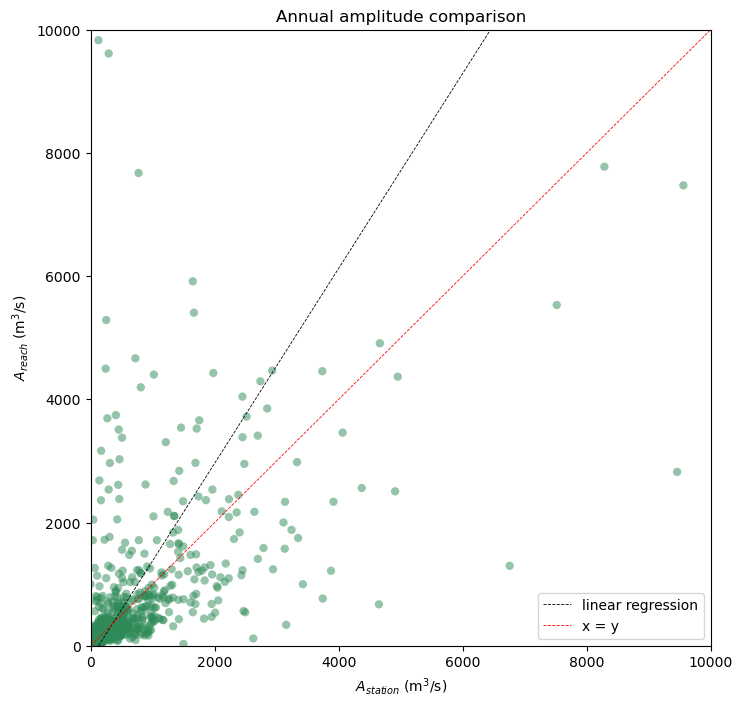

In [104]:
# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(ampli_g, ampli_s, c='seagreen', alpha=0.5, edgecolors='none')

# Linear regression
a, b = np.polyfit(ampli_g, ampli_s, deg=1)
plt.axline(xy1=(0, b), slope=a, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# X = y slope
xy = np.arange(np.nanmax(ampli_g))
s, d = np.polyfit(xy, xy, deg=1)
plt.axline(xy1=(0, d), slope=s, label=f'x = y', color='r', linestyle='--', linewidth = 0.6)

# Titles
plt.ylim((0,10000))
plt.xlim((0,10000))
plt.title("Annual amplitude comparison") 
plt.legend()
plt.xlabel(r'$A_{station}$ (m$^3$/s)')
plt.ylabel(r'$A_{reach}$ (m$^3$/s)')

# Save
fig_name = f'ampli_year_4nn_a10000.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()

#### Mean relative discharge difference vs. distance

ValueError: x and y must be the same size

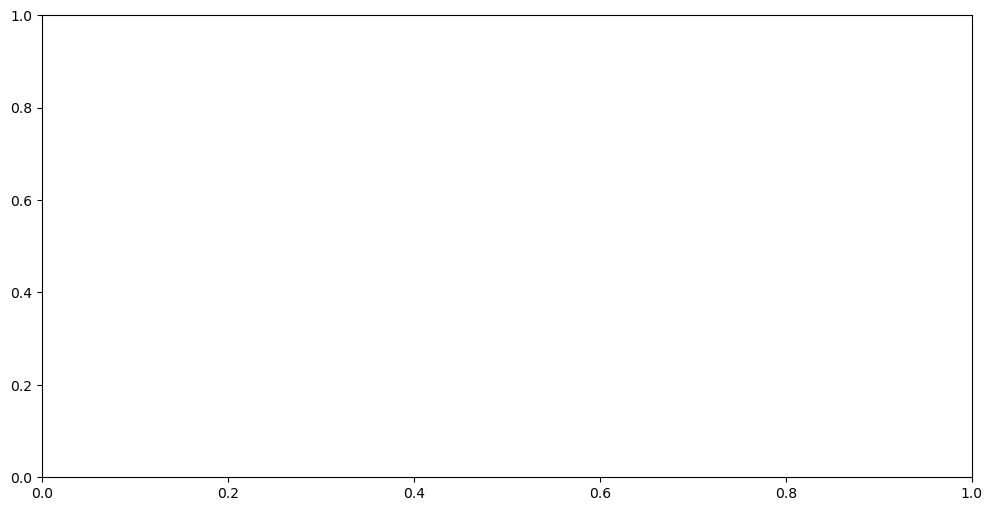

In [105]:
# Log
log_err = np.log10(bias) # (2840,)

# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(distance, bias, c='seagreen', alpha=0.5, edgecolors='none')

# Titles
"""plt.ylim((-10000,10000))
plt.xlim((0,100))"""
plt.title("SWOT relative error as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'$\varepsilon_r$ (%)')

# Save
fig_name = f'dschg_vs_dist.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Pdf of the distances

48.986621539759305
-> Percentage of reaches at less than 10km distance from the station: 72.73
Figure saved.


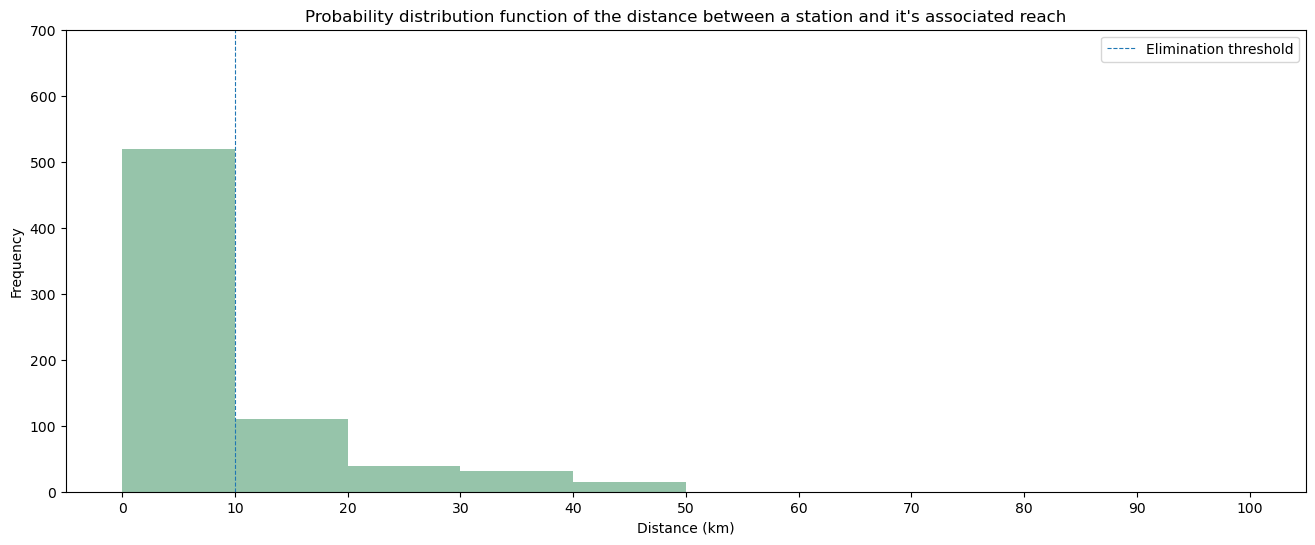

In [ ]:
# Percentage of reaches at 10km or less from the station (ignore nans)
d_10km = len((distance[distance<=10]))
n_total = len(distance)
ration_10km = d_10km/n_total*100
print(f"-> Percentage of reaches at less than 10km distance from the station: {ration_10km:.2f}") # 48%

# Clipping the very high values (including infinites) to a defined maximum
max = 100
min = 0
clip_dist = np.clip(distance,min,max)

# Plot
plt.figure(figsize=(16, 6))
n_bins = 10
step = (max-min)/n_bins
my_bins = np.arange(min,max+1,step)
plt.hist(clip_dist, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.axvline(x=10,label=f'Elimination threshold', color='tab:blue', linestyle='--', linewidth = 0.8)
plt.title(f"Probability distribution function of the distance between a station and it's associated reach") 
plt.ylim((0,700))
plt.xticks(my_bins)
plt.xlabel('Distance (km)') 
plt.ylabel('Frequency')
plt.legend()

# Save
fig_name = f'pdf_dist_10nn.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print("Figure saved.")
plt.show()


#### Width vs discharge for swot

Figure saved in /obs/ecastonguay/scripts/figures


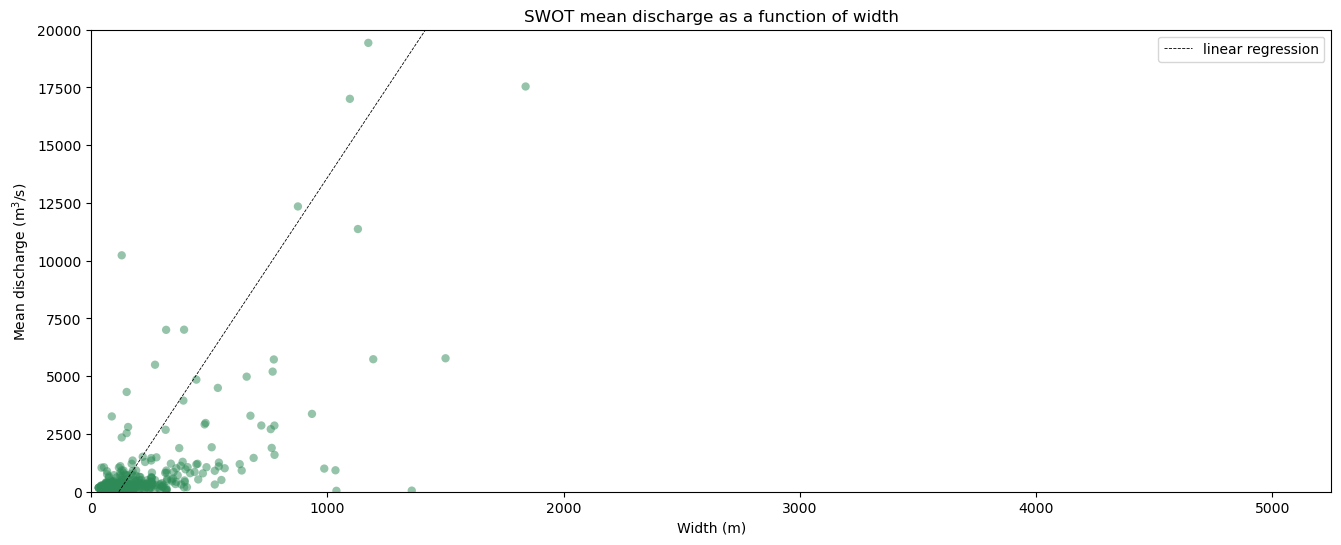

In [ ]:
# Discharge
q_s = q_ol_s.mean(dim="time")

# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(w_ol_swr, q_s, c='seagreen', alpha=0.5, edgecolors='none')

# Linear regression
ss, bb = np.polyfit(w_ol_swr, q_s, deg=1)
plt.axline(xy1=(0, bb), slope=ss, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# Titles
plt.ylim((0,20000))
plt.xlim((0,np.nanmax(w_ol_swr)))
plt.title("SWOT mean discharge as a function of width") 
plt.legend()
plt.xlabel(r'Width (m)')
plt.ylabel(r'Mean discharge (m$^3$/s)')

# Save
fig_name = f'dschg_vs_w.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### Scatter of correlation vs. width

/tmp/ipykernel_1652/1187231310.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved in /obs/ecastonguay/scripts/figures


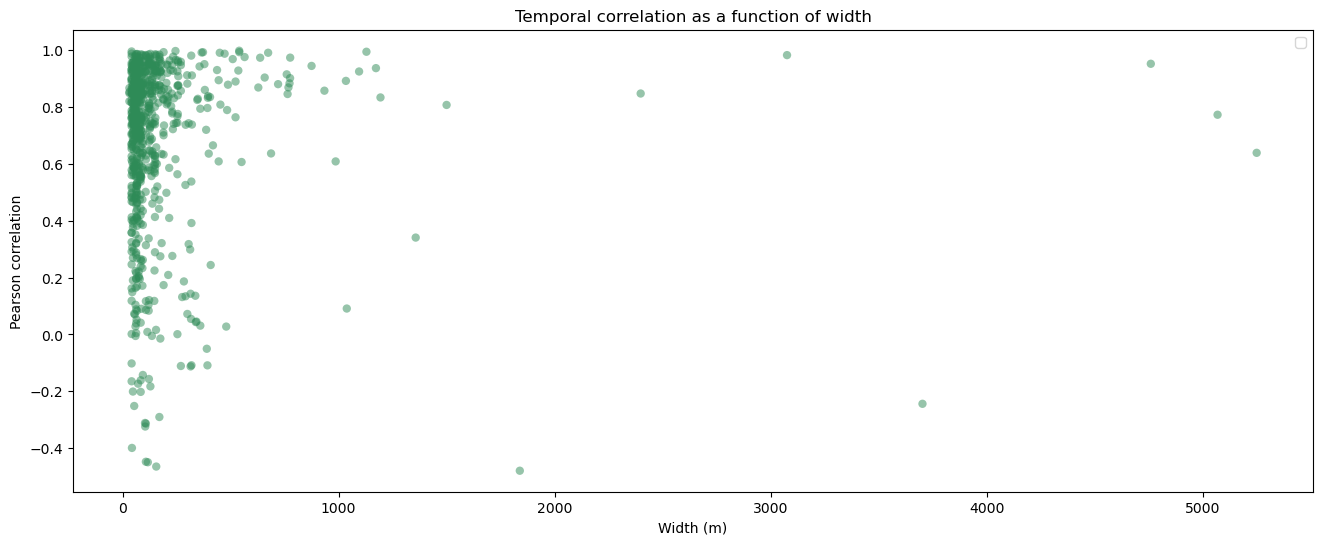

In [ ]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(w_ol_swr, r_matrix, c='seagreen', alpha=0.5, edgecolors='none')

"""# Linear regression
ss, bb = np.polyfit(w_ol_swr, r_matrix, deg=1)
plt.axline(xy1=(0, bb), slope=ss, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)"""

# Titles
"""plt.ylim((0,20000))
plt.xlim((0,np.nanmax(w_ol_swr)))"""
plt.title("Temporal correlation as a function of width") 
plt.legend()
plt.xlabel(r'Width (m)')
plt.ylabel(r'Pearson correlation')

# Save
fig_name = f'corr_vs_w.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Pdf of corr vs. width

Figure saved in /obs/ecastonguay/scripts/figures


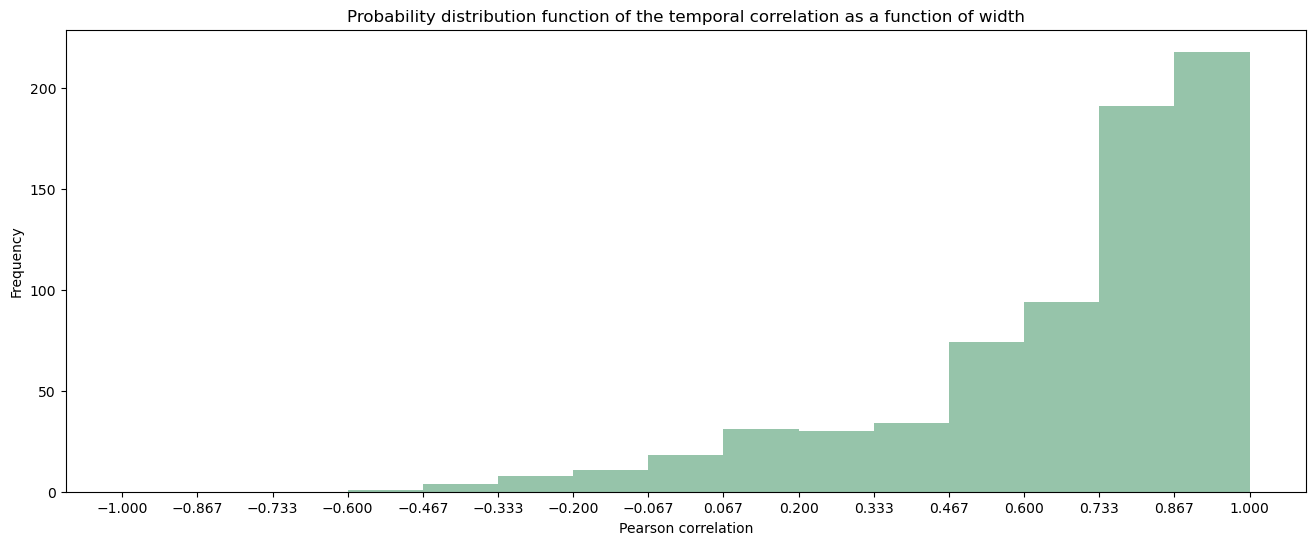

In [ ]:
# Clipping the very high values (including infinites) to a defined maximum
max = 1
min = -1
n_bins = 10
step = (max-min)/n_bins
"""clip_dist = np.clip(distance,min,max)"""

# Plot
plt.figure(figsize=(16, 6))
my_bins = np.linspace(-1, 1, 16)
plt.hist(r_matrix, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.title(f"Probability distribution function of the temporal correlation as a function of width") 
#plt.ylim((0,1750))
plt.xticks(my_bins)
plt.xlabel('Pearson correlation') 
plt.ylabel('Frequency')

# Save
fig_name = f'pdf_corr.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


#### (10 best pearson coef.)

In [ ]:
# Correlations
corr2 = np.where(np.isnan(r_matrix), -np.inf, corr)
assert corr2.shape == id_ol_g.shape == corr.shape

# Ids of the n best
n_best = 10
print("-> Stations having the best pearson coeff. correlation (worst to best):")
ind_best = np.argpartition(corr2, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(corr2[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
pearson_10_best = []
pearson_10_best.append(id_ol_g[ind_best_sorted])
print(pearson_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr2[ind_best_sorted][b]}")

# Median of the distribution
median_da = corr.median(skipna=True)
median_id_g = id_ol_g[corr==median_da]
print("-> Median value")
print(f"Station id: {median_id_g}. Pearson coeff. value: {median_da.values}")

## Results for n best:
# [4149122, 3634200, 3649618, 3634320, 6335060, 6645020, 3618090, 3666050, 2591800, 3627001]
## Results for median: 
# 5405070

"""for i in range(n_best):
    ind_max = np.nanargmax(corr_dlt)
    print(f"Station id: {station_id_dlt[ind_max]}. Pearson coeff. value: {corr_dlt[ind_max]}")
    # retain station ids
    id_pearson_g.append(station_id_dlt[ind_max])
    # delete
    corr_dlt = np.delete(corr_dlt,ind_max)
    station_id_dlt = np.delete(station_id_dlt,ind_max)

print(id_pearson_g)


n_nans = np.isnan(corr).sum() # using count of NaNs to offset and thus compute indices and extract values; https://stackoverflow.com/questions/56377996/using-numpy-argpartition-ignoring-nans
ind_best = np.argpartition(corr, -n_best-n_nans)[-n_best-n_nans:-n_nans] 
ind_best_sorted = ind_best[np.argsort(corr[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value
# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr[ind_best_sorted][b]}")
"""

-> Stations having the best pearson coeff. correlation (worst to best):
[array([3618721, 4103550, 3649619, 4207900, 6545800, 3638200, 4127800,
       4149122, 3649618, 3618720])]
Station id: 3618721. Pearson coeff. value: 0.9902770048960053
Station id: 4103550. Pearson coeff. value: 0.9903702768367539
Station id: 3649619. Pearson coeff. value: 0.9912355243254151
Station id: 4207900. Pearson coeff. value: 0.992165427084641
Station id: 6545800. Pearson coeff. value: 0.9924355333394749
Station id: 3638200. Pearson coeff. value: 0.9925534371554184
Station id: 4127800. Pearson coeff. value: 0.9938985368455232
Station id: 4149122. Pearson coeff. value: 0.994941805671489
Station id: 3649618. Pearson coeff. value: 0.9965540810421529
Station id: 3618720. Pearson coeff. value: 0.9974919368503775
-> Median value
Station id: []. Pearson coeff. value: 0.7700270568407277


'for i in range(n_best):\n    ind_max = np.nanargmax(corr_dlt)\n    print(f"Station id: {station_id_dlt[ind_max]}. Pearson coeff. value: {corr_dlt[ind_max]}")\n    # retain station ids\n    id_pearson_g.append(station_id_dlt[ind_max])\n    # delete\n    corr_dlt = np.delete(corr_dlt,ind_max)\n    station_id_dlt = np.delete(station_id_dlt,ind_max)\n\nprint(id_pearson_g)\n\n\nn_nans = np.isnan(corr).sum() # using count of NaNs to offset and thus compute indices and extract values; https://stackoverflow.com/questions/56377996/using-numpy-argpartition-ignoring-nans\nind_best = np.argpartition(corr, -n_best-n_nans)[-n_best-n_nans:-n_nans] \nind_best_sorted = ind_best[np.argsort(corr[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value\n# Print\nfor b in range(len(ind_best_sorted)):\n    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr[ind_best_sorted][b]}")\n'

#### NSE world map

/tmp/ipykernel_1652/3137370828.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  nse_value = 1 - mse/var_obs


Figure saved in /obs/ecastonguay/scripts/figures


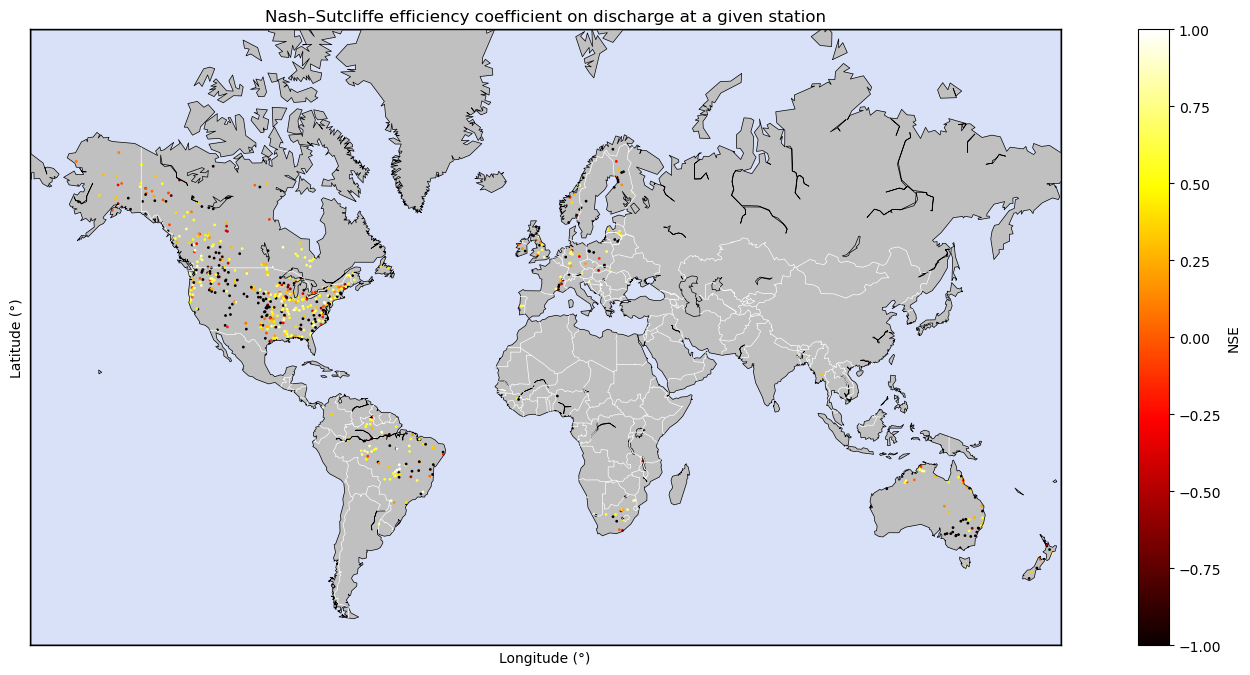

In [ ]:
# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='silver', lake_color='silver')
#map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=nse_array, cmap='hot', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='NSE')
plt.title("Nash–Sutcliffe efficiency coefficient on discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'nse_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### (10 best NSE)

In [ ]:
# NSE
nse2_array = np.where(np.isnan(nse_array), -np.inf, nse_array)

# Ids of the n best
n_best = 10
print("-> Stations having the best NSE (worst to best):")
ind_best = np.argpartition(nse2_array, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(nse2_array[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
assert id_ol_g.shape == nse2_array.shape
nse_10_best = []
nse_10_best.append(id_ol_g[ind_best_sorted])
print(nse_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. NSE value: {nse2_array[ind_best_sorted][b]}")

# Median of the distribution
median_da = np.nanmedian(nse_array) # using nse_array with nan values, not nse2_array 
median_index = (np.abs(nse_array - median_da)).argmin()
median_id_g = id_ol_g[median_index]
print("-> Median value")
print(f"Station id: {median_id_g}. NSE value: {median_da}")

## Results for n best:
# [3633121, 4147720, 3635402, 3631500, 3649618, 3649409, 6335060, 3649424, 3649619, 3618090]
## Results for median: 
# 6335030

-> Stations having the best NSE (worst to best):
[array([4148541, 3652870, 3638200, 4123202, 4147720, 4207020, 6545800,
       3649618, 3649424, 3649619])]
Station id: 4148541. NSE value: 0.9357085630986166
Station id: 3652870. NSE value: 0.936778496007093
Station id: 3638200. NSE value: 0.9378288060556826
Station id: 4123202. NSE value: 0.9455076801030794
Station id: 4147720. NSE value: 0.9519344810373574
Station id: 4207020. NSE value: 0.9525958494636585
Station id: 6545800. NSE value: 0.9574249868441675
Station id: 3649618. NSE value: 0.9627231512079996
Station id: 3649424. NSE value: 0.9731039296236789
Station id: 3649619. NSE value: 0.9749201471800608
-> Median value
Station id: 4235300. NSE value: 0.25976886740172966


#### Areas scatter plot

/tmp/ipykernel_1652/4088635573.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved.


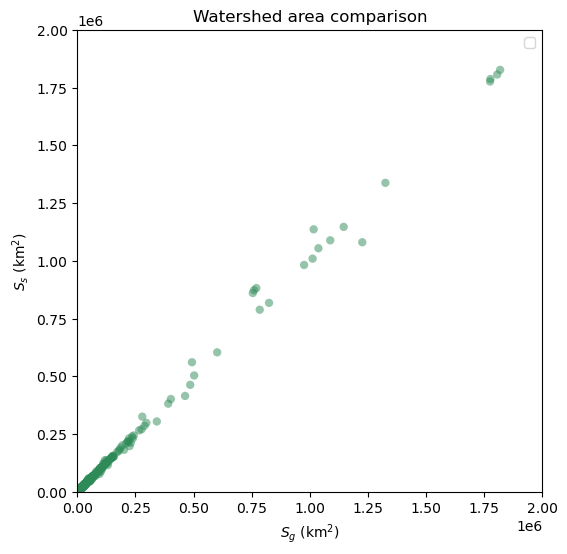

In [ ]:
# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(area_ol_g, area_ol_s, c='seagreen', alpha=0.5, edgecolors='none')

"""# Linear regression
a, b = np.polyfit(ampli_g, ampli_s, deg=1)
plt.axline(xy1=(0, b), slope=a, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# X = y slope
xy = np.arange(np.nanmax(ampli_g))
s, d = np.polyfit(xy, xy, deg=1)
plt.axline(xy1=(0, d), slope=s, label=f'x = y', color='r', linestyle='--', linewidth = 0.6)"""

# Titles
plt.ylim((0,2000000))
plt.xlim((0,2000000))
plt.title("Watershed area comparison") 
plt.legend()
plt.xlabel(r'$S_g$ (km$^2$)')
plt.ylabel(r'$S_s$ (km$^2$)')

# Save
fig_name = f'area_scatter.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()